Importing the libraries

In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and Processing

In [7]:
# Loading the gold price data from a CSV file into a pandas DataFrame
df=pd.read_csv(r"C:\Users\admin\OneDrive\Desktop\Jupyter Notebook\gld_price_data.csv")

In [8]:
# Display the first 5 rows of the dataframe 

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [10]:
# Display the last 5 rows of the dataframe
df.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [13]:
# Get the dimensions of the dataframe (number of rows, number of columns)
df.shape

(2290, 6)

In [16]:
# Display concise summary of the DataFrame 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [18]:
# Check for missing values in the dataframe

df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [20]:
# Generate descriptive statistics for the DataFrame

df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


**Correlation:** 
1. Positive Correlation
2. Negative Correlation

In [24]:
correlation = df.corr(numeric_only=True)

<Axes: >

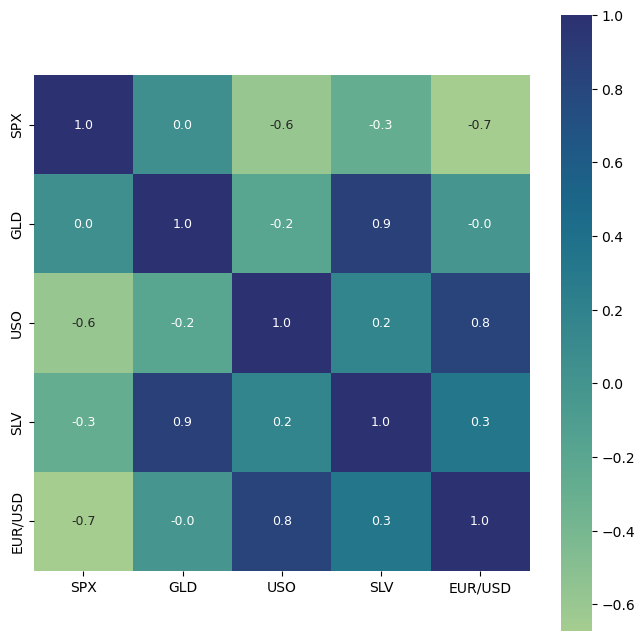

In [74]:
# Create a figure with 8x8 size (in inches)
plt.figure(figsize = (8,8))
# Generate a heatmap visualization of the correlation matrix 
sns.heatmap(correlation,cbar=True,square = True,fmt='.1f',annot = True, annot_kws={'size':9},cmap='crest')

In [40]:
# Correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


<Axes: xlabel='GLD', ylabel='Count'>

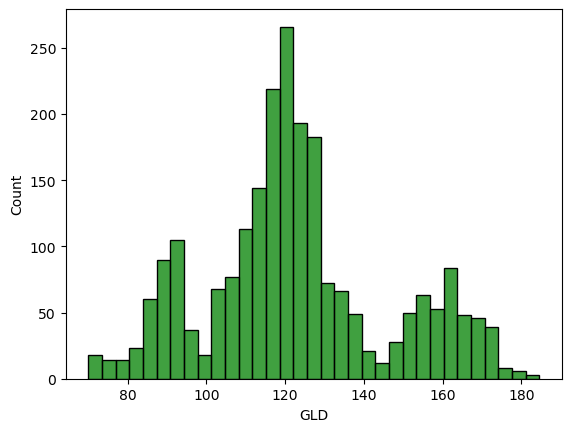

In [44]:
#Checking the distribution of the GLD Price
sns.histplot(df['GLD'],color='green')

In [49]:
X = df.drop(["Date","GLD"],axis=1)
Y = df['GLD']

In [50]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [51]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into Training data and Test data

In [56]:
X_train,X_test,Y_train,Y_test= train_test_split(
    X,
    Y,
    test_size =0.2,
    random_state=42)

Model Training : Random Forest Regressor

In [57]:
regressor = RandomForestRegressor(n_estimators=100)

In [58]:
#training the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation

In [59]:
#prediction on test data
test_data_prediction = regressor.predict(X_test)

In [60]:
print(test_data_prediction)

[122.49579962 130.58120272 127.5928994   96.65719765 119.06550062
 114.43249916 124.64900152 117.74439984 108.0324013   98.19159972
  95.27049947 167.05039862 149.18310123 116.18740058 170.6756014
  84.93419961 123.22439877 109.12039662 113.23880074 131.51690363
 124.33189889 113.47990053 115.61120064 108.78910005 108.88530131
 125.84239913 119.20649949 112.17849914 113.66490173 125.52429908
 145.79070152  89.44419997 167.62320008 113.80419932 108.26500092
 120.16680128 141.95949875 161.2371014  174.21089745 153.14470169
 119.67310103 113.5073003  121.39219945 113.70339931 121.94660024
 107.86390055  88.48529894 114.4479991  130.1050026  117.93480119
 103.99380056 129.9188028  107.15229851 160.60800405 131.44670054
 118.69369997 147.33250011 136.36100256  95.62650106 124.63950163
 115.37639873  85.99620103 104.34599913 114.01410061  84.25919922
 122.21099997 116.73759887 113.64480203 164.6472029   92.15020024
  80.30100108 161.08530076 158.01060238 106.87279984 148.10210142
 109.724497

In [63]:
# R squared error
error_score = metrics.r2_score(Y_test,test_data_prediction)
print("R squared error :",error_score)

R squared error : 0.9911667398152588


Compare the Actual Values and Predicted values in a plot

In [64]:
Y_test = list(Y_test)

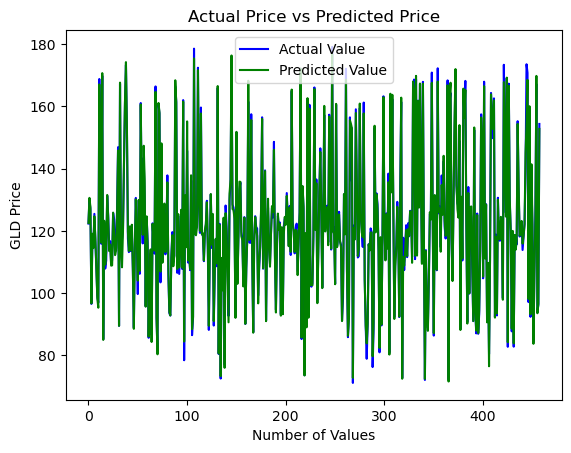

In [66]:
plt.plot(Y_test,color='blue',label="Actual Value")
plt.plot(test_data_prediction,color ="green",label="Predicted Value")
plt.title("Actual Price vs Predicted Price")
plt.xlabel("Number of Values")
plt.ylabel("GLD Price")
plt.legend()
plt.show()